# Bài tập buổi 13: Xây dựng mạng MLP trên EMNIST

Đề bài : Xây dựng pipeline huấn luyện một mạng MLP (Multi-Layer Perceptron) để phân loại **chữ cái in hoa** trong dataset **EMNIST** (A–Z, 26 lớp).

Mục tiêu:
- Tải và chuẩn bị dữ liệu EMNIST bằng `torchvision`.
- Định nghĩa mô hình MLP bằng `nn.Module`.
- Viết vòng lặp huấn luyện và đánh giá.
- Trực quan hóa kết quả và lưu mô hình.

Kết quả tham khảo: MLP đơn giản này thường đạt khoảng **85–90%** accuracy trên tập test.

## 1. Import và cấu hình

Import các thư viện cần thiết rồi đặt các tham số huấn luyện.

Gợi ý: `BATCH_SIZE = 256`, `EPOCHS = 5`, `LEARNING_RATE = 1e-3`. Chọn `DEVICE` là `cuda` nếu có GPU, ngược lại dùng `cpu`.

In [11]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torchvision import datasets, transforms

# TODO: đặt BATCH_SIZE, EPOCHS, LEARNING_RATE, DATA_DIR
# TODO: chọn DEVICE là 'cuda' nếu torch.cuda.is_available(), ngược lại 'cpu'
BATCH_SIZE = 256
EPOCHS = 5
LEARNING_RATE = 1e-3
DATA_DIR = './data'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(0)

print(f'PyTorch: {torch.__version__}')
print(f'Thiết bị: {DEVICE}')

PyTorch: 2.13.0+cpu
Thiết bị: cpu


## 2. Dataset và DataLoader

Tải dataset EMNIST với `split='letters'` (26 lớp chữ cái in hoa A–Z, ảnh xám 28×28).

- Dùng `transforms.Compose([transforms.ToTensor()])` để đổi ảnh thành tensor.
- Tách tập train gốc (124.800 mẫu) thành **100.000 mẫu train** và **24.800 mẫu validation**.
- Tạo 3 `DataLoader` với `batch_size=BATCH_SIZE`; chỉ `train_loader` cần `shuffle=True`.

In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
])
target_transform = transforms.Lambda(lambda y: y - 1)

full_train = datasets.EMNIST(DATA_DIR, split='letters', train=True,
                              transform=transform, target_transform=target_transform,
                              download=True)
test_set = datasets.EMNIST(DATA_DIR, split='letters', train=False,
                            transform=transform, target_transform=target_transform,
                            download=True)

# TODO: dùng random_split tách full_train thành train_set (100.000) và val_set (24.800)
# TODO: tạo train_loader, val_loader, test_loader với batch_size=BATCH_SIZE
train_set, val_set = random_split(
    full_train, [100_000, 24_800],
    generator=torch.Generator().manual_seed(0)
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE)


print(len(train_set), len(val_set), len(test_set))

100000 24800 20800


## 3. Khám phá dữ liệu

In shape của một batch rồi vẽ vài ảnh đầu tiên để xem dữ liệu trông như thế nào.

Lưu ý: nhãn là số nguyên 0–25, tương ứng với chữ cái A–Z. Có thể đổi sang ký tự bằng `chr(nhãn + ord('A'))`.

Batch ảnh : torch.Size([256, 1, 28, 28])
Batch nhãn: torch.Size([256])


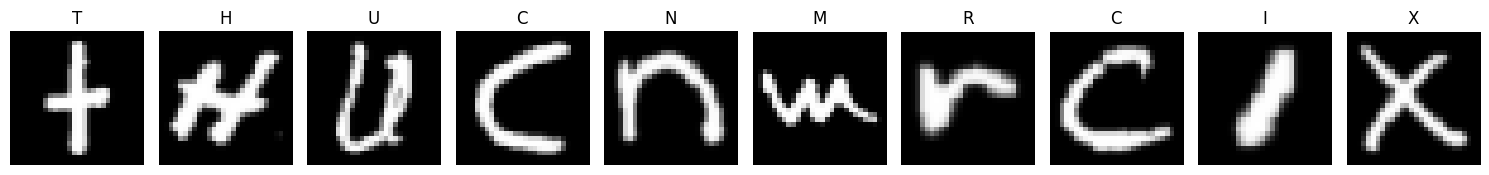

In [13]:
batch_images, batch_labels = next(iter(train_loader))
print('Batch ảnh :', batch_images.shape)
print('Batch nhãn:', batch_labels.shape)

# TODO: vẽ 10 ảnh đầu tiên của batch (cmap='gray'), tiêu đề mỗi ảnh là nhãn dạng chữ cái
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    img = batch_images[i].squeeze().T
    ax.imshow(img, cmap='gray')
    ax.set_title(chr(batch_labels[i].item() + ord('A')))
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Định nghĩa MLP

Xây dựng lớp `EMNISTMLP` kế thừa `nn.Module`.

Gợi ý cấu trúc: `Flatten` → `Linear(784, 128)` → `ReLU` → `Linear(128, 26)`.
Chú ý: 784 = 28×28 (kích thước ảnh sau khi dẹt), 26 = số lớp chữ cái.

In [14]:
class EMNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: định nghĩa các layer
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 26)
    def forward(self, images):
        # TODO: cho images đi qua các layer
        x = self.flatten(images)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
        pass

model = EMNISTMLP().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

print(model)

EMNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=26, bias=True)
)


## 5. Vòng lặp huấn luyện và đánh giá

Viết 2 hàm:

- `train_one_epoch`: với mỗi batch, thực hiện `zero_grad` → forward → tính loss → `backward` → `step`. Cộng dồn loss và số dự đoán đúng.
- `evaluate`: giống vòng lặp trên nhưng **không cập nhật trọng số**, dùng `model.eval()` và `torch.no_grad()`.

Cả hai hàm trả về `(loss trung bình, accuracy)`.

In [15]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    # TODO: lặp qua các batch, cập nhật trọng số, cộng dồn loss và số dự đoán đúng
    # Gợi ý: số dự đoán đúng = (logits.argmax(dim=1) == labels).sum().item()
    for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
    
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
    
            total_loss += loss.item() * images.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += images.size(0)
    return total_loss / total_samples, total_correct / total_samples

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    # TODO: giống train_one_epoch nhưng bỏ qua backward/step và dùng torch.no_grad()
    with torch.no_grad():
            for images, labels in loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
    
                logits = model(images)
                loss = criterion(logits, labels)
    
                total_loss += loss.item() * images.size(0)
                total_correct += (logits.argmax(dim=1) == labels).sum().item()
                total_samples += images.size(0)
    return total_loss / total_samples, total_correct / total_samples

## 6. Huấn luyện

Chạy vòng lặp qua `EPOCHS` epoch. Mỗi epoch: train 1 epoch trên `train_loader`, đánh giá trên `val_loader`, lưu loss/accuracy vào các list và in kết quả.

In [16]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    # TODO: gọi train_one_epoch và evaluate, lưu kết quả vào 4 list
    # TODO: in dạng: Epoch {epoch}: train loss=..., val loss=..., train acc=..., val acc=...
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f'Epoch {epoch}: train loss={train_loss:.4f}, val loss={val_loss:.4f}, '
        f'train acc={train_acc:.2%}, val acc={val_acc:.2%}')

Epoch 1: train loss=1.2330, val loss=0.8637, train acc=66.21%, val acc=75.72%
Epoch 2: train loss=0.7229, val loss=0.6416, train acc=79.40%, val acc=81.43%
Epoch 3: train loss=0.5685, val loss=0.5410, train acc=83.52%, val acc=84.29%
Epoch 4: train loss=0.4884, val loss=0.4870, train acc=85.64%, val acc=85.79%
Epoch 5: train loss=0.4371, val loss=0.4539, train acc=86.98%, val acc=86.57%


## 7. Đánh giá và trực quan hóa

1. Vẽ 2 biểu đồ cạnh nhau: **Loss** và **Accuracy** theo epoch (so sánh train vs val).
2. Đánh giá mô hình trên `test_loader` (tập chưa từng dùng khi huấn luyện).
3. Lấy 1 batch từ `test_loader`, vẽ 10 ảnh với nhãn thật và nhãn dự đoán (xanh = đúng, đỏ = sai).

Test loss=0.4572, test accuracy=86.64%


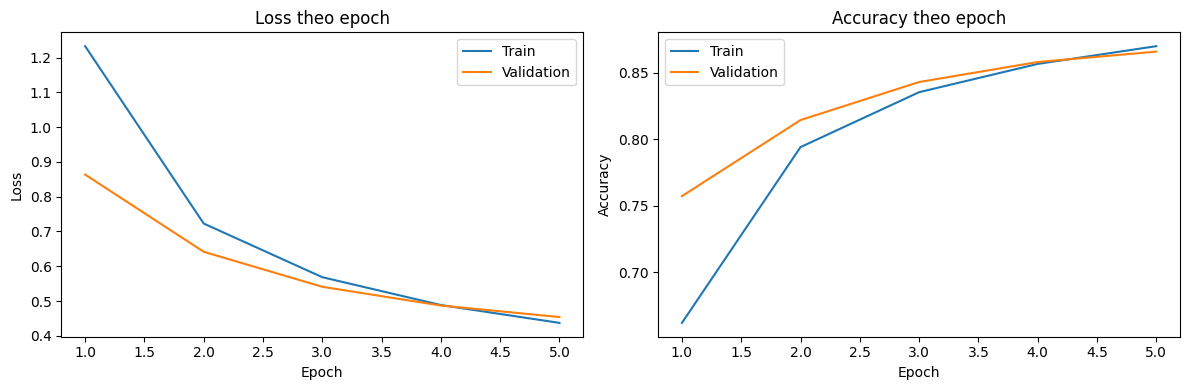

Test loss=0.4572, test accuracy=86.64%


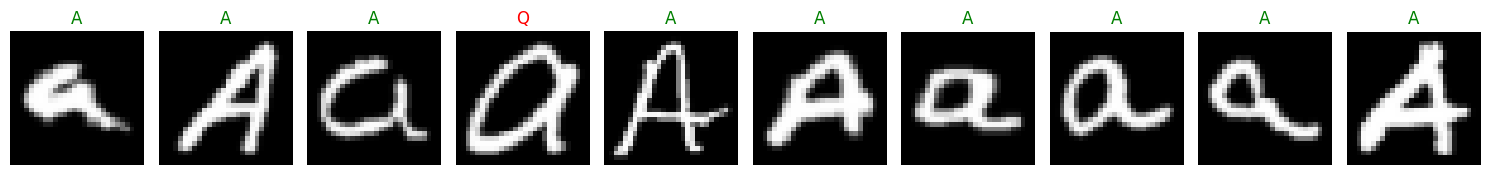

In [19]:
# TODO: vẽ đồ thị Loss và Accuracy theo epoch (train vs val)

test_loss, test_accuracy = evaluate(model, test_loader, criterion)
print(f'Test loss={test_loss:.4f}, test accuracy={test_accuracy:.2%}')

# TODO: lấy 1 batch từ test_loader và vẽ 10 ảnh kèm nhãn thật + nhãn dự đoán
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_losses, label='Train')
axes[0].plot(epochs_range, val_losses, label='Validation')
axes[0].set_title('Loss theo epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_range, train_accuracies, label='Train')
axes[1].plot(epochs_range, val_accuracies, label='Validation')
axes[1].set_title('Accuracy theo epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

test_loss, test_accuracy = evaluate(model, test_loader, criterion)
print(f'Test loss={test_loss:.4f}, test accuracy={test_accuracy:.2%}')

model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(DEVICE), labels.to(DEVICE)
with torch.no_grad():
    preds = model(images).argmax(dim=1)

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    img = images[i].squeeze().cpu().T
    true_label = chr(labels[i].item() + ord('A'))
    pred_label = chr(preds[i].item() + ord('A'))
    color = 'green' if true_label == pred_label else 'red'
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{pred_label}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Lưu mô hình

Lưu trọng số của mô hình bằng `state_dict` để dùng lại sau này.

In [20]:
# TODO: lưu state_dict của model vào file 'emnist_mlp.pt'
torch.save(model.state_dict(), 'emnist_mlp.pt')
print('Đã lưu mô hình vào emnist_mlp.pt')

Đã lưu mô hình vào emnist_mlp.pt
